<a href="https://colab.research.google.com/github/Cris-19-77-99/EDP/blob/main/Informe_EDP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Paquetes de Python




In [ ]:
import numpy as np
from numpy.linalg import eigvals, norm
import pandas as pd
import matplotlib.pyplot as plt
from scipy.linalg import expm
from scipy.special import legendre
from mpl_toolkits.mplot3d import Axes3D
import time


# Algoritmos de métodos utilizados


## Algoritmo para obtener operador diferencial discretizado para problema generalizado

In [ ]:
def matriz_op_seg_derivada(n):
  matrix = np.zeros((n, n))
  np.fill_diagonal(matrix, -2)
  np.fill_diagonal(matrix[1:], 1)
  np.fill_diagonal(matrix[:, 1:], 1)
  return matrix

def matriz_op_prim_derivada_centrada(n):
  matrix = np.zeros((n, n))
  np.fill_diagonal(matrix[1:], -1)
  np.fill_diagonal(matrix[:, 1:], 1)
  return matrix

def edp_lineal(a2_func, a1_func, a0_func, f_no_homo,coef_borde_ini, coef_borde_fin , n, L):

  A1, B1, C1 = coef_borde_ini
  A2, B2, C2 = coef_borde_fin
  dx = L / (n - 1)
  xx = np.linspace(0, L, n)
  x = xx[1:n-1]

  e_ini = 1 / (dx * A1 - B1)
  e_fin = 1 / (dx * A2 + B2)

  d2 = 1 / (dx ** 2) * (matriz_op_seg_derivada(n - 2) +  np.diag([-B1*e_ini if i == 0 else B2*e_fin if i == n - 3 else 0 for i in range(n - 2)]))

  d1 = 1 / (2*dx) * (matriz_op_prim_derivada_centrada(n - 2) + np.diag([B1*e_ini if i == 0 else B2*e_fin if i == n - 3 else 0 for i in range(n - 2)]))


  a2_matrix = np.diag([a2_func(xi) for xi in xx[1:n-1]])
  a1_matrix = np.diag([a1_func(xi) for xi in xx[1:n-1]])
  a0_matrix = np.diag([a0_func(xi) for xi in xx[1:n-1]])

  L = a2_matrix @ d2 + a1_matrix @ d1 + a0_matrix


  no_homogeneo = 1 / (dx) * np.array(C1*[e_ini] + [0] * (n - 2) + C2*[e_fin]) + np.array(C1*[-e_ini] + [0] * (n - 2) + C2*[e_fin]) - np.array([f_no_homo(xi) for xi in xx[1:n-1]])
  return L, no_homogeneo
############# Ejemplo #####################
def f_no_homo(x):
  return 0

def a2_func(x):
  return 1

def a1_func(x):
  return 1

def a0_func(x):
  return 0

coef_borde_ini= [0 , 1 , 0]
coef_borde_fin= [0 , 1 , 0]
n = 6
L = 10

L, no_homogeneo= edp_lineal(a2_func, a1_func, a0_func, f_no_homo ,coef_borde_ini,coef_borde_fin, n, L)

print("L_matrix:")
print(L)
print("no_homogeneo:")
print(no_homogeneo)


L_matrix:
[[-0.5  0.5  0.   0. ]
 [ 0.  -0.5  0.5  0. ]
 [ 0.   0.  -0.5  0.5]
 [ 0.   0.   0.   0. ]]
no_homogeneo:
[0. 0. 0. 0.]


El método presentado genera el operador diferencial asociado a una ecuación diferencial parcial homogénea con condiciones de borde tipo Robin y funciones de coeficientes dependientes de $x$. La ecuación a resolver es:

$$
a_2(x)\frac{∂^2u}{∂x^2}+a_1(x)\frac{∂u}{∂x}+a_2(x)u=0
$$

La implementación calcula las matrices de discretización para los términos de segunda y primera derivada, aplicando condiciones de borde tipo Robin en ambos extremos del dominio.

## Algoritmo que ejecuta el método de Euler Explicito

In [ ]:
def euler_explicito_dt(A, dt):
  n = A.shape[0]
  Id = np.identity(n)
  T = Id + dt * A
  T_eigvals = np.linalg.eigvals(T)
  norm_T = np.linalg.norm(T, ord=2)
  return T, T_eigvals, norm_T

La función euler_eplicito_dt implementa el método de Euler explícito para resolver sistemas de ecuaciones diferenciales de la forma
$$
\frac{d\vec{u}}{dt}= A\vec{u}  
$$
con un paso temporal dt. En este caso, el método devuelve la matriz de transición, sus valores propios y su norma, lo cual permite analizar la estabilidad del sistema en función de dt.



## 1.    Algoritmo que ejecuta la integración numerica por aproximación trapesoidal

## 2.   Algoritmo que ejecuta el métodod de Galerkin(Elementos finitos) utilizando calculo de integrales con el método trapesoidal.




In [ ]:
def trapesio_simple(f, a, b):
    return (b - a) * (f(a) + f(b)) / 2

# def f(x):
#     return np.sin(x)

# a = 0
# b = 1
# resultado = trapesio_simple(f, a, b)

# print(resultado)

Este código implementa el método del trapecio simple para aproximar la integral definida de una función $f(x)$ en el intervalo $[a,b]$. El método del trapecio utiliza una aproximación lineal para la función en el intervalo, calculando el área bajo la curva como la de un trapecio.

In [ ]:
####### Codigo Bueno #####
def galerkin(f, p, q, g_inicial, N, L, dt,M):
  dx = L / (N - 1)
  xx = np.linspace(0, L, N)
  m=0
  # ##############################################################################
  c=np.zeros(N)
  num_cond=[]

  while m <= M:
    if m == 0:
      c = np.array([g_inicial(xx)])
      m = m + 1
    else:
      A = np.zeros((N-2, N-2))
      integral_iA= lambda x, x_ii: p(x)+(1/dt + q(x))*(x-x_ii)**2
      integral_iB= lambda x, x_ii,x_i: p(x)+(1/dt + q(x))*(x-x_ii)*(x-x_i)

      diag_valores = (1/dx**2) * (trapesio_simple(lambda x: integral_iA(x, xx[0:-2]), xx[0:-2], xx[1:-1]) +
                                  trapesio_simple(lambda x: integral_iA(x, xx[2:]), xx[1:-1], xx[2:]))

      diag_sup_valores= -(1/dx**2) * (trapesio_simple(lambda x: integral_iB(x,xx[2:],xx[1:-1]), xx[1:-1], xx[2:]))

      A[0:, 0:] = np.diag(diag_valores)
      np.fill_diagonal(A[1:], diag_sup_valores)
      np.fill_diagonal(A[:,1:], diag_sup_valores)

    # ##############################################################################

      F = np.zeros(N-2)

      integral_iC = lambda x, x_ii, i: (f(x) + c[m-1][i] / dt) * (x - x_ii)

      F_valores = (1 / dx) * (trapesio_simple(lambda x: integral_iC(x, xx[0:-2], np.arange(1, len(xx)-1)), xx[0:-2], xx[1:-1]) -
                              trapesio_simple(lambda x: integral_iC(x, xx[2:], np.arange(1, len(xx)-1)), xx[1:-1], xx[2:]))

      F[0:] = F_valores

      # ##############################################################################

      c_new = np.linalg.solve(A,F)

      c0 = 0
      c1 = 0

      c_new=np.insert(c_new,0,c0)
      c_new=np.insert(c_new,N-1,c1)

      c=np.vstack([c, c_new])
      num_cond.append(np.linalg.cond(A))
      m = m + 1
  return c,num_cond


## 1.    Algoritmo que ejecuta la integración numerica por método de Gauss Legendre.

## 2.   Algoritmo que ejecuta el métodod de Galerkin(Elementos finitos) utilizando calculo de integrales con el método de Gauss Legendre.

In [ ]:
def gauss_legendre_pesos(n):
    raices = np.roots(legendre(n))
    pesos = []
    for i in range(n):
        peso = 2 / ((1 - raices[i]**2) * (legendre(n).deriv(1)(raices[i]))**2)
        pesos.append(peso)

    return pesos,raices


def cuadratura_gaussiana(g, a, b, pesos , nodos):
  integral = 0
  N=len(pesos)
  for i in range(N):
    xi = ((b - a)*(nodos[i]+1))/2 + a
    integral += pesos[i] * g(xi)

  return  ((b - a)/2)*integral

 El codigo anterior calcula los nodos (raíces) y los pesos para la cuadratura de Gauss-Legendre de orden $n$. Estos nodos y pesos son necesarios para evaluar una integral utilizando los puntos de Gauss-Legendre.

In [ ]:
def galerkin_gauss_legendre(f, p, q, g_inicial, N, a, b, dt,M,Nc):

  dx = (b-a) / (N - 1)
  xx = np.linspace(a, b, N)
  m = 0
  pesos, raices = gauss_legendre_pesos(Nc)

  # ##############################################################################
  c=np.zeros(N)

  num_cond=[]

  while m <= M:
    if m == 0:
      c = np.array([g_inicial(xx)])
      m = m + 1
    else:
      A = np.zeros((N-2, N-2))
      integral_iA= lambda x, x_ii: p(x)+(1/dt + q(x))*(x-x_ii)**2
      integral_iB= lambda x, x_ii,x_i: p(x)+(1/dt + q(x))*(x-x_ii)*(x-x_i)

      diag_valores = (1/dx**2) * (cuadratura_gaussiana(lambda x: integral_iA(x, xx[0:-2]), xx[0:-2], xx[1:-1],pesos, raices) +
                                  cuadratura_gaussiana(lambda x: integral_iA(x, xx[2:]), xx[1:-1], xx[2:],pesos, raices))


      diag_sup_valores= -(1/dx**2) * (cuadratura_gaussiana(lambda x: integral_iB(x,xx[2:],xx[1:-1]), xx[1:-1], xx[2:],pesos, raices))

      A[0:, 0:] = np.diag(diag_valores)
      np.fill_diagonal(A[1:], diag_sup_valores)
      np.fill_diagonal(A[:,1:], diag_sup_valores)

    # ##############################################################################

      F = np.zeros(N-2)

      integral_iC = lambda x, x_ii, i: (f(x) + c[m-1][i] / dt) * (x - x_ii)

      F_valores = (1/dx)* (cuadratura_gaussiana(lambda x: integral_iC(x, xx[0:-2],np.arange(1, len(xx)-1)), xx[0:-2], xx[1:-1],pesos, raices) -
                              cuadratura_gaussiana(lambda x: integral_iC(x, xx[2:],np.arange(1, len(xx)-1)), xx[1:-1], xx[2:],pesos, raices))

      F[0:] = F_valores

      # ##############################################################################

      c_new = np.linalg.solve(A,F)

      c0 = 0
      c1 = 0

      c_new=np.insert(c_new,0,c0)
      c_new=np.insert(c_new,N-1,c1)

      c=np.vstack([c, c_new])
      num_cond.append(np.linalg.cond(A))
      m = m + 1
  return c,num_cond

Se implementó el método de Galerkin con cuadratura de Gauss-Legendre para resolver una ecuación diferencial con condiciones de frontera específicas en un dominio espacial de longitud L.

## Método que contruye la matriz extendida del operador para problemas 2 dimensionales con condiciones de borde homogeneneas.

In [ ]:
def matriz_central(a5_func, a4_func, a2_func, a0_func, xi, yi, n, dx, dy):
  matrix = np.zeros((n, n))
  np.fill_diagonal(matrix, -2*( a5_func(xi,yi)/dx**2 + a4_func(xi,yi)/dy**2 ) + a0_func(xi,yi))
  np.fill_diagonal(matrix[1:], a5_func(xi,yi)/dx**2 + a2_func(xi,yi)/(2*dx))
  np.fill_diagonal(matrix[:, 1:], a5_func(xi,yi)/dx**2 + a2_func(xi,yi)/(2*dx))
  return matrix

def matriz_superior(a4_func, a3_func, a1_func, xi, yi, n, dx, dy):
  matrix = np.zeros((n, n))
  np.fill_diagonal(matrix, (1/dy)*( a4_func(xi,yi)/dy + a1_func(xi,yi)/2 ))
  np.fill_diagonal(matrix[1:], a3_func(xi,yi)/(4*dx*dy))
  np.fill_diagonal(matrix[:,1:], -a3_func(xi,yi)/(4*dx*dy))
  return matrix

def matriz_inferior(a4_func, a3_func, a1_func, xi, yi, n, dx, dy):
  matrix = np.zeros((n, n))
  np.fill_diagonal(matrix, (1/dy)*( a4_func(xi,yi)/dy - a1_func(xi,yi)/2 ))
  np.fill_diagonal(matrix[1:], -a3_func(xi,yi)/(4*dx*dy))
  np.fill_diagonal(matrix[:,1:], a3_func(xi,yi)/(4*dx*dy))
  return matrix

def edp_lineal_orden_2( f, a5_func, a4_func, a3_func, a2_func, a1_func, a0_func , N, M, Ln, Lm):

  dx = 1 / (N - 1)
  dy = 1 / (M - 1)
  xi = np.linspace(0, Ln, N)
  yi = np.linspace(0, Lm, M)

  x = xi[1:N-1]
  y = xi[1:M-1]


  n=N-2
  m=M-2

  C = matriz_central(a5_func, a4_func, a2_func, a0_func, x, y, n, dx, dy)
  S = matriz_superior(a4_func, a3_func, a1_func, x, y, n, dx, dy)
  I = matriz_inferior(a4_func, a3_func, a1_func, x, y, n, dx, dy)


  matrix = np.zeros((n*m, n*m))
  for i in range(m):
      matrix[n * i:n * (i + 1), n * i:n * (i + 1)] = C
      if i > 0:
          matrix[n * i:n * (i + 1), n * (i - 1):n * i] = I
      if i < m - 1:
          matrix[n * i:n * (i + 1), n * (i + 1):n * (i + 2)] = S

  F=np.array([f(i, j) for i in x for j in y])

  return matrix,F

Este código define un sistema de ecuaciones diferenciales parciales (EDP) de segundo orden.  La función edp_lineal_orden_2 discretiza el dominio espacial en una malla de tamaño $N\times M$ y construye la matriz completa del sistema, ensamblando una matriz global matrix para el sistema lineal.

# Resultados Informe I curso EDP

## Problema 1

Resolucion del problema Informe 1 de EDP. Consideramos el problema

$$
\begin{align}
\frac{∂u}{∂t}=D\frac{∂u^2}{∂x^2} && x\in[0,1] && t>0
\end{align}
$$
sujeto a:
$$
\begin{align}
u(0,t)=0\\
u(1,t)=0\\
u(x,0)=\sin(x\pi)
\end{align}
$$

In [ ]:
def a2_func(x):
   return 1

def a1_func(x):
   return 0

def a0_func(x):
   return 0

coef_borde_ini= [1 , 0 , 0]
coef_borde_fin= [1 , 0 , 0]
n =100
L = 1
M=200
T_max=10
dt=T_max/M
A, no_homogeneo= edp_lineal(a2_func, a1_func, a0_func, coef_borde_ini,coef_borde_fin, n, L)

In [ ]:
# print("L_matrix:")
# print(L)
# print("no_homogeneo:")
# print(no_homogeneo)

In [ ]:
T, T_valores_propios, norma_T = euler_explicito_dt(A, dt)

In [ ]:
def u0(x):
  return np.sin(x*np.pi)

def solucion_analitica(x, t):
  return np.sin(x*np.pi)*np.exp(-t*np.pi**2)

xx = np.linspace(0, L, n)

U0 = u0(xx[1:-1])

<ipython-input-20-5845446c5020>:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = plt.cm.get_cmap('viridis', len(range(M)))


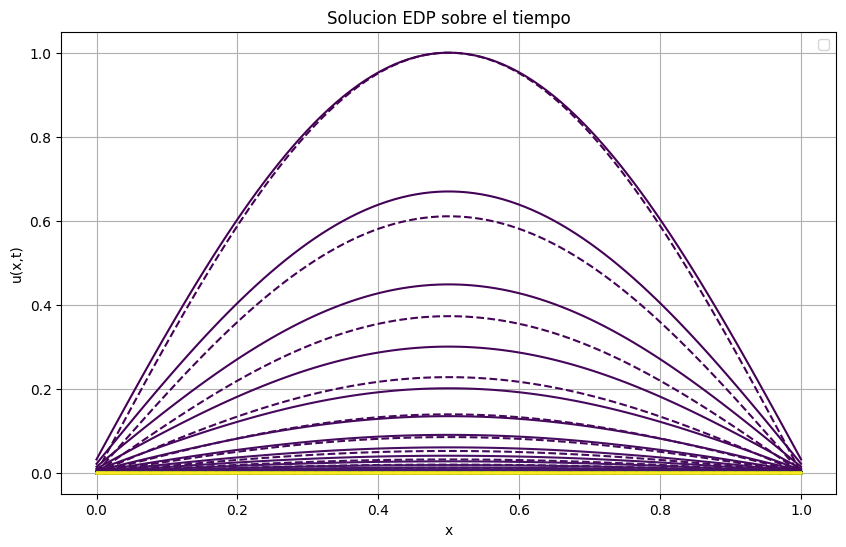

In [ ]:
x_values = np.linspace(0, 1, n -2 )


Tiempos = np.arange(0, M * dt, dt)

colors = plt.cm.get_cmap('viridis', len(range(M)))

# Create the plot
plt.figure(figsize=(10, 6))

for m in range(M):
  U = U0 @ np.linalg.matrix_power(T,m)
  plt.plot(x_values, U, color=colors(m))
  plt.plot(x_values, solucion_analitica(x_values, Tiempos[m]), color=colors(m), linestyle='--')

plt.xlabel('x')
plt.ylabel('u(x,t)')
plt.title('Solucion EDP sobre el tiempo')
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
f = lambda x: 0
g = lambda x: np.sin(np.pi * x)
p = lambda x: 1
q = lambda x: 0
a=0
b=1
N = 100

coef_borde_ini = (1, 0, 0)
coef_borde_fin = (1, 0, 0)
dt=0.01
M=10
c_galerkin = galerkin(f, p, q, g, N, L, dt, M)
solucion_aprox_trapesoidal = c_galerkin[0]
num_cond_trapesoidal = c_galerkin[1]

c_galerkin_gauss_legendre = galerkin_gauss_legendre(f, p, q, g, N, a, b, dt, M, 6)
solucion_aprox_gauss_legendre = c_galerkin_gauss_legendre[0]
num_cond_gauss_legendre = c_galerkin_gauss_legendre[1]

<ipython-input-22-1675a2693d88>:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = plt.cm.get_cmap('viridis', len(range(M)))


<Figure size 1000x600 with 0 Axes>

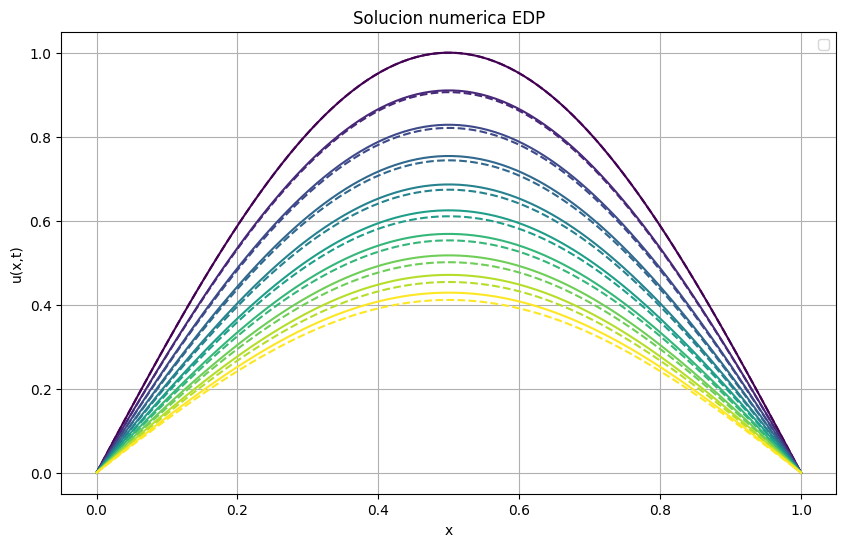

In [ ]:
num_timesteps = solucion_aprox_trapesoidal.shape[0]

x_values = np.linspace(0, L, N)
Tiempos = np.arange(0, M * dt, dt)

plt.figure(figsize=(10, 6))
colors = plt.cm.get_cmap('viridis', len(range(M)))

plt.figure(figsize=(10, 6))

for m in range(M):
  plt.plot(x_values, solucion_aprox_trapesoidal[m], color = colors(m))
  plt.plot(x_values, solucion_analitica(x_values, Tiempos[m]), color=colors(m), linestyle='--')


plt.xlabel('x')
plt.ylabel('u(x,t)')
plt.title('Solucion numerica EDP')
plt.legend()
plt.grid(True)
plt.show()

<ipython-input-23-5093588dcbaf>:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = plt.cm.get_cmap('viridis', len(range(M)))


<Figure size 1000x600 with 0 Axes>

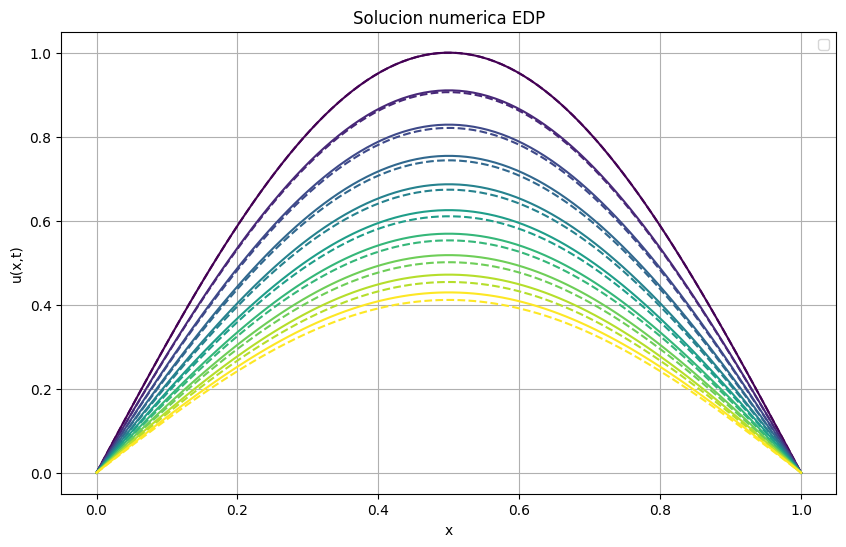

In [ ]:
num_timesteps = solucion_aprox_gauss_legendre.shape[0]

x_values = np.linspace(0, L, N)
Tiempos = np.arange(0, M * dt, dt)

plt.figure(figsize=(10, 6))
colors = plt.cm.get_cmap('viridis', len(range(M)))

plt.figure(figsize=(10, 6))

for m in range(M):
  plt.plot(x_values, solucion_aprox_gauss_legendre[m][:], color = colors(m))
  plt.plot(x_values, solucion_analitica(x_values, Tiempos[m]), color=colors(m), linestyle='--')


plt.xlabel('x')
plt.ylabel('u(x,t)')
plt.title('Solucion numerica EDP')
plt.legend()
plt.grid(True)
plt.show()

## Problema 2
Consideremos la ecuación de Poisson en dos dimensiones:

\begin{align}
−\Delta u = f(x, y), && (x, y) \in \Omega = [0, 1] \times [0, 1],
\end{align}

donde la función fuente $f(x, y)$ está dada por:

$$
f(x, y) = 2\pi^{2}\sin(\pi x)\sin(\pi y).
$$

Las condiciones de frontera de tipo Dirichlet se aplican en todos los bordes
de la región:

\begin{align}
u(x, y) = 0, && \text{para} && (x, y) ∈ \partial\Omega.
\end{align}

La solución exacta para este problema es:
$$
u_{exact}(x, y) = \sin(\pi x)\sin(\pi y)
$$

In [ ]:
def a5_func(x,y):
  return -1

def a4_func(x,y):
  return -1

def a3_func(x,y):
  return 0

def a2_func(x,y):
  return 0

def a1_func(x,y):
  return 0

def a0_func(x,y):
  return 0


def f(x, y):
    return (2 * np.pi**2) * np.sin(np.pi * x) * np.sin(np.pi * y)

N=10
M=10

In [ ]:
A,F=edp_lineal_orden_2( f, a5_func, a4_func, a3_func, a2_func, a1_func, a0_func , N, M, 1, 1)

In [ ]:
u = np.linalg.solve(A, F)

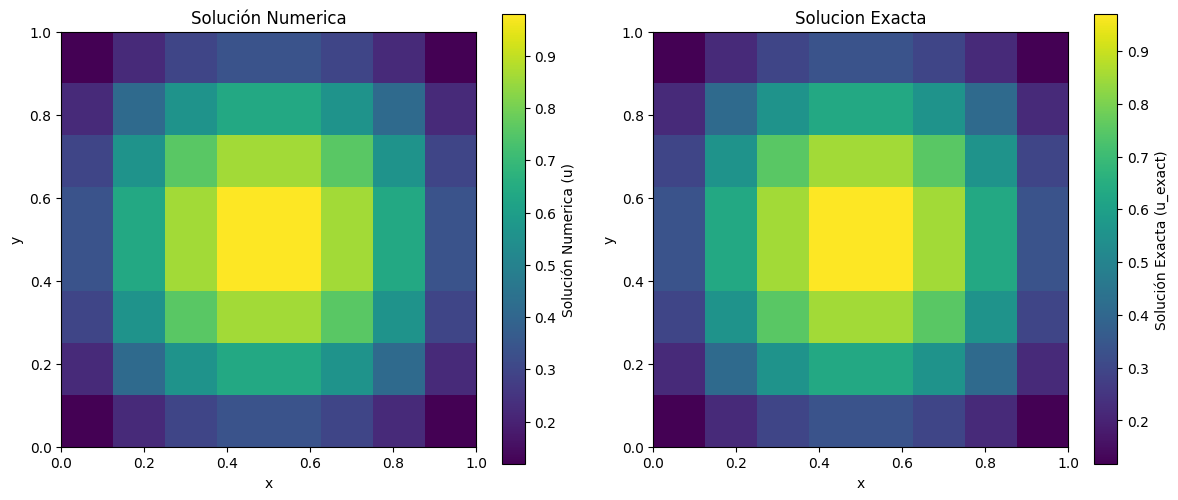

Error: 0.04597234004785755


In [ ]:
u_reshaped = u.reshape((N - 2, M - 2))

x = np.linspace(0, 1, N)[1:N-1]
y = np.linspace(0, 1, M)[1:M-1]
X, Y = np.meshgrid(x, y)
u_exact = np.sin(np.pi * X) * np.sin(np.pi * Y)


plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(u_reshaped, extent=[0, 1, 0, 1], origin='lower', cmap='viridis')
plt.colorbar(label='Solución Numerica (u)')
plt.title('Solución Numerica')
plt.xlabel('x')
plt.ylabel('y')


plt.subplot(1, 2, 2)
plt.imshow(u_exact, extent=[0, 1, 0, 1], origin='lower', cmap='viridis')
plt.colorbar(label='Solución Exacta (u_exact)')
plt.title('Solucion Exacta')
plt.xlabel('x')
plt.ylabel('y')

plt.tight_layout()
plt.show()

# Calculate and print the error
error = np.linalg.norm(u_reshaped - u_exact)
print(f"Error: {error}")

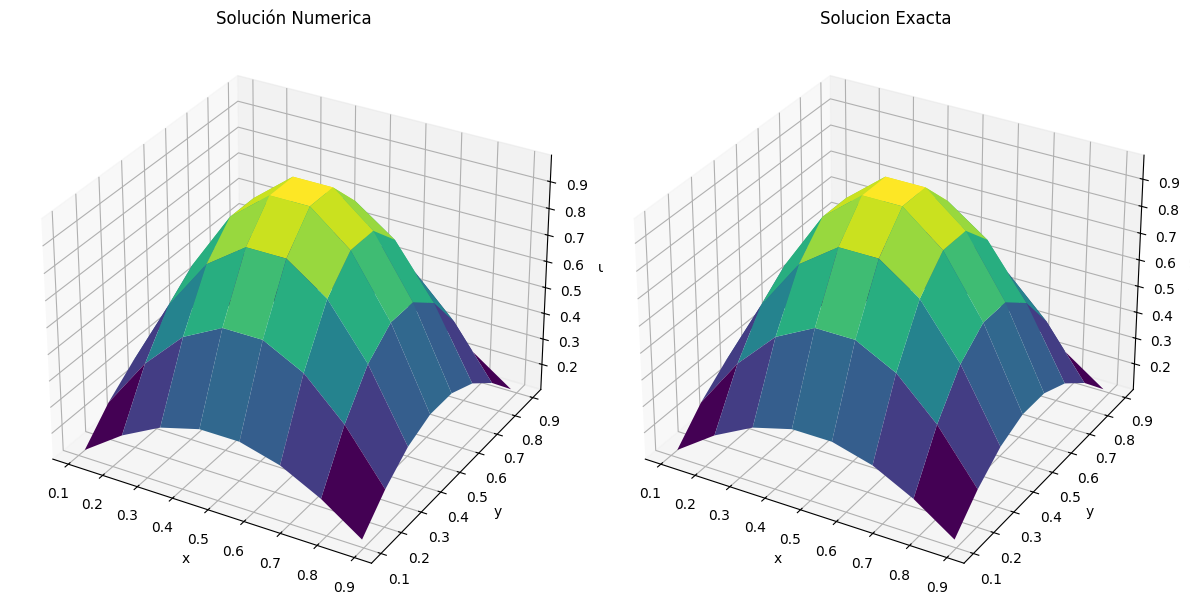

In [ ]:
fig = plt.figure(figsize=(12, 6))

ax1 = fig.add_subplot(121, projection='3d')
ax1.plot_surface(X, Y, u_reshaped, cmap='viridis')
ax1.set_title('Solución Numerica')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_zlabel('u')

ax2 = fig.add_subplot(122, projection='3d')
ax2.plot_surface(X, Y, u_exact, cmap='viridis')
ax2.set_title('Solucion Exacta')
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_zlabel('u_exact')

plt.tight_layout()
plt.show()

## Tablase de resultados Problema 1

In [ ]:
def f_no_homo(x):
   return 0
def a1_func(x):
   return 0

def a0_func(x):
   return 0

def u0(x):
  return np.sin(x*np.pi)

def solucion_analitica(x, t):
  return np.sin(x*np.pi)*np.exp(-t*np.pi**2)


coef_borde_ini= [1 , 0 , 0]
coef_borde_fin= [1 , 0 , 0]
L = 1

T_max = 10
L = 1
N_vals = [20, 100, 200]
M_vals = [100, 1000,10000]
D_vals=[-1,0.01,1,100]


resultados = []
for param in D_vals:
  a2_func = lambda x: param
  for n in N_vals:
      dx = L / (n - 1)
      x_vals = np.linspace(0, L, n - 2)

      for m in M_vals:
          dt = T_max / m
          Tiempos = np.arange(0, m * dt, dt)

          A, no_homogeneo = edp_lineal(a2_func, a1_func, a0_func, f_no_homo, coef_borde_ini, coef_borde_fin, n, L)

          u_exacta_final = solucion_analitica(x_vals, Tiempos[-1])

          T, T_eigvals, norm_T = euler_explicito_dt(A, dt)

          U0 = u0(x_vals)

          u_aprox = U0 @ np.linalg.matrix_power(T, m)

          max_eigenvalue = max(abs(T_eigvals))
          Estabilidad = max_eigenvalue <= 1

          error = np.linalg.norm(u_exacta_final - u_aprox)

          resultados.append({
              'D': param,
              'D*dt/dx^2': param*dt/(dx**2),
              'Norma T': norm_T,
              'Estabilidad': 'Estable' if Estabilidad else 'Inestable',
              'Error': error
          })

  tabla_resultados = pd.DataFrame(resultados)

tabla_resultados_ordenada = tabla_resultados.sort_values('D*dt/dx^2')
for D_vals, tabla_dx in tabla_resultados_ordenada.groupby('D'):
    print(f"               Resultados para D = {D_vals}")
    print(tabla_dx)
    print("\n" + "-"*40 + "\n")



/usr/local/lib/python3.10/dist-packages/numpy/linalg/linalg.py:680: RuntimeWarning: overflow encountered in matmul
  result = z if result is None else fmatmul(result, z)
/usr/local/lib/python3.10/dist-packages/numpy/linalg/linalg.py:677: RuntimeWarning: overflow encountered in matmul
  z = a if z is None else fmatmul(z, z)
<ipython-input-19-3333a3b1014f>:46: RuntimeWarning: invalid value encountered in matmul
  u_aprox = U0 @ np.linalg.matrix_power(T, m)
/usr/local/lib/python3.10/dist-packages/numpy/linalg/linalg.py:680: RuntimeWarning: invalid value encountered in matmul
  result = z if result is None else fmatmul(result, z)
/usr/local/lib/python3.10/dist-packages/numpy/linalg/linalg.py:677: RuntimeWarning: invalid value encountered in matmul
  z = a if z is None else fmatmul(z, z)


               Resultados para D = -1.0
     D  D*dt/dx^2       Norma T Estabilidad  Error
6 -1.0  -3960.100  15840.413060   Inestable    NaN
3 -1.0   -980.100   3920.413122   Inestable    NaN
7 -1.0   -396.010   1584.941306   Inestable    NaN
4 -1.0    -98.010    392.941312   Inestable    NaN
8 -1.0    -39.601    159.394131   Inestable    NaN
0 -1.0    -36.100    144.415286   Inestable    inf
5 -1.0     -9.801     40.194131   Inestable    NaN
1 -1.0     -3.610     15.341529   Inestable    NaN
2 -1.0     -0.361      2.434153   Inestable    NaN

----------------------------------------

               Resultados para D = 0.01
       D  D*dt/dx^2     Norma T Estabilidad     Error
11  0.01    0.00361    0.999902     Estable  1.081767
10  0.01    0.03610    0.999015     Estable  1.081294
14  0.01    0.09801    0.999901     Estable  2.595118
9   0.01    0.36100    0.990153     Estable  1.076552
17  0.01    0.39601    0.999901     Estable  3.698713
13  0.01    0.98010    2.919413   Inestable

In [ ]:
def calculo_tabla(f, exact_solution, a5_func, a4_func, a3_func, a2_func, a1_func, a0_func, tamaños):
    results = []

    for N in tamaños:
        M = N
        dx = 1 / (N - 1)
        dy = 1 / (M - 1)

        # Tiempo de inicio
        start_time = time.time()

        # Construir matriz A y vector F
        A, F = edp_lineal_orden_2(f, a5_func, a4_func, a3_func, a2_func, a1_func, a0_func, N, M, 1, 1)

        # Resolver el sistema
        u_num = np.linalg.solve(A, F)

        # Tiempo de fin
        elapsed_time = time.time() - start_time

        # Generar malla para calcular la solución exacta
        x = np.linspace(0, 1, N)
        y = np.linspace(0, 1, M)
        x, y = np.meshgrid(x[1:-1], y[1:-1])  # Excluir los bordes
        u_exact = exact_solution(x, y).flatten()

        # Calcular normas
        l2_norm = np.sqrt(np.sum((u_exact - u_num)**2) * dx * dy)
        linf_norm = np.max(np.abs(u_exact - u_num))

        # Guardar resultados
        results.append({
            "N x M": f"{N} x {M}",
            "dx, dy": dx,
            "L2 Norm": l2_norm,
            "Linf Norm": linf_norm,
            "Tiempo de simulación (s)": elapsed_time
        })

    return results

def u_exact(x, y):
    return np.sin(np.pi * x) * np.sin(np.pi * y)

def a5_func(x,y):
  return -1

def a4_func(x,y):
  return -1

def a3_func(x,y):
  return 0

def a2_func(x,y):
  return 0

def a1_func(x,y):
  return 0

def a0_func(x,y):
  return 0


def f(x, y):
    return (2 * np.pi**2) * np.sin(np.pi * x) * np.sin(np.pi * y)

Tamaños = [10, 20, 40, 60, 80, 120, 140, 160]

results = calculo_tabla(f, u_exact, a5_func, a4_func, a3_func, a2_func, a1_func, a0_func, Tamaños)


df = pd.DataFrame(results)
print(df)

df.to_csv("results.csv", index=False)


N_values = [int(value.split(" x ")[0]) for value in df["N x M"]]  # Assuming "N x M" column format
times = df["Tiempo de ejecución (s)"]


plt.figure(figsize=(10, 6))
plt.plot(N_values, times, marker='o')
plt.xlabel("N")
plt.ylabel("Tiempo de ejecución (s)")
plt.title("N vs. Tiempo de ejecución")
plt.grid(True)
plt.show()

       N x M    dx, dy   L2 Norm  Linf Norm  Tiempo de simulación (s)
0    10 x 10  0.111111  0.005108   0.009908                  0.002105
1    20 x 20  0.052632  0.001141   0.002266                  0.005337
2    40 x 40  0.025641  0.000270   0.000540                  0.114736
3    60 x 60  0.016949  0.000118   0.000236                  1.107152
4    80 x 80  0.012658  0.000066   0.000132                  6.088992
5  120 x 120  0.008403  0.000029   0.000058                 62.584578
6  140 x 140  0.007194  0.000021   0.000043                151.149524
7  160 x 160  0.006289  0.000016   0.000033                329.494500


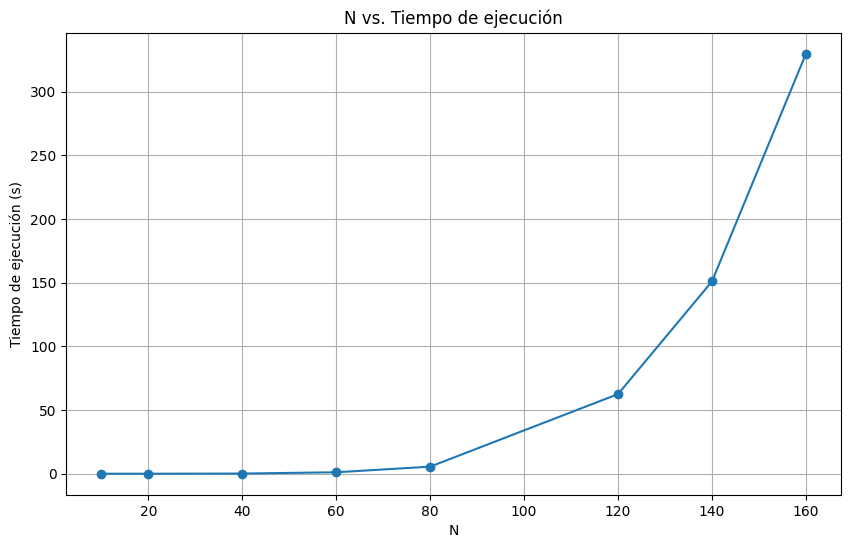

In [ ]:
# prompt: Con el resultado anterior hace un grafico donde se tenga N vs Tiempo de ejecucion.



In [ ]:
def solucion_analitica(x, t):
    return np.sin(x * np.pi) * np.exp(-t * np.pi**2)

def calcular_error(sol_num, sol_analitica):
    return np.linalg.norm(sol_num - sol_analitica) / np.linalg.norm(sol_analitica)

# Parámetros comunes
a, b = 0, 1
g = lambda x: np.sin(np.pi * x)
f = lambda x: 0
p = lambda x: 1
q = lambda x: 0

# Valores de dt/dx a probar
relaciones_dt_dx = [0.1, 0.5, 1, 2, 5]
N = 1000  # Número de puntos espaciales
M = 10   # Iteraciones temporales

# Tablas de resultados
resultados = []

for relacion in relaciones_dt_dx:
    dx = (b - a) / (N - 1)
    dt = relacion * dx
    xx = np.linspace(a, b, N)
    t_max = dt * M
    tiempos = np.linspace(0, t_max, M + 1)

    sol_analitica = np.array([solucion_analitica(xx, t) for t in tiempos])

    # Resolver con ambos métodos
    c_gauss_legendre = galerkin_gauss_legendre(f, p, q, g, N, a, b, dt, M, 6)
    c_galerkin = galerkin(f, p, q, g, N, b - a, dt, M)

    # Calcular errores
    error_gauss_legendre = calcular_error(c_gauss_legendre[0], sol_analitica)
    error_galerkin = calcular_error(c_galerkin[0], sol_analitica)

    condicion_gauss_legendre = max(c_gauss_legendre[1])
    condicion_galerkin =  max(c_galerkin[1])

    resultados.append({
        "dt/dx": relacion,
        "Error Gauss-Legendre": error_gauss_legendre,
        "Error Galerkin": error_galerkin,
        "Condicionamiento Gauss-Legendre": condicion_gauss_legendre,
        "Condicionamiento Galerkin": condicion_galerkin
    })

# Convertir resultados a DataFrame
df_resultados = pd.DataFrame(resultados)

# Mostrar las tablas

print(df_resultados.to_string(index=False))


 dt/dx  Error Gauss-Legendre  Error Galerkin  Condicionamiento Gauss-Legendre  Condicionamiento Galerkin
   0.1              0.000013        0.000003                       399.538283                 400.203632
   0.5              0.000081        0.000071                      1988.508960                1989.169086
   1.0              0.000288        0.000279                      3957.234575                3957.888259
   2.0              0.001085        0.001076                      7837.466376                7838.107456
   5.0              0.006021        0.006013                     19039.799150               19040.404529


In [ ]:
# prompt: Quiero cambiar la tabla comparativa de galerkin. Quiero que para 4 valores de dx fijo me crees 4 tablas: en cada tabla tendras las columnas: dt,  Error Gauss-Legendre,  Error Galerkin,  Condicionamiento Gauss-Legendre,  Condicionamiento Galerkin

def solucion_analitica(x, t):
    return np.sin(x * np.pi) * np.exp(-t * np.pi**2)

def calcular_error(sol_num, sol_analitica):
    return np.linalg.norm(sol_num - sol_analitica)

# Parámetros comunes
a, b = 0, 1
g = lambda x: np.sin(np.pi * x)
f = lambda x: 0
p = lambda x: 1
q = lambda x: 0

# Valores de dx a probar
dx_vals = [0.1, 0.05, 0.01, 0.005]
dt_vals = [0.1, 0.05, 0.01 ,0.005]

for dx in dx_vals:
    # Calcular N basado en el dx dado
    N = int(1 / dx) + 1

    resultados = []

    for dt in dt_vals:
        M = int(1 / dx) + 1
        xx = np.linspace(a, b, N)
        t_max = dt * M
        tiempos = np.linspace(0, t_max, M + 1)
        sol_analitica_vals = np.array([solucion_analitica(xx, t) for t in tiempos])

        # Resolver con ambos métodos
        c_gauss_legendre = galerkin_gauss_legendre(f, p, q, g, N, a, b, dt, M, 6)
        c_galerkin = galerkin(f, p, q, g, N, b - a, dt, M)

        # Calcular errores
        error_gauss_legendre = calcular_error(c_gauss_legendre[0], sol_analitica_vals)
        error_galerkin = calcular_error(c_galerkin[0], sol_analitica_vals)

        condicion_gauss_legendre = np.max(c_gauss_legendre[1]) if len(c_gauss_legendre[1])>0 else 0 # Handle empty list
        condicion_galerkin = np.max(c_galerkin[1]) if len(c_galerkin[1])>0 else 0 #Handle empty list

        resultados.append({
            "dt": dt,
            "Error Gauss-Legendre": error_gauss_legendre,
            "Error Trapesoidal": error_galerkin,
            "Condicionamiento Gauss-Legendre": condicion_gauss_legendre,
            "Condicionamiento Trapesoidal": condicion_galerkin
        })

    # Convertir resultados a DataFrame y mostrar la tabla
    df_resultados = pd.DataFrame(resultados)
    print(f"Tabla para dx = {dx}")
    print(df_resultados.to_string(index=False))
    print("\n" + "-"*40 + "\n")

Tabla para dx = 0.1
   dt  Error Gauss-Legendre  Error Trapesoidal  Condicionamiento Gauss-Legendre  Condicionamiento Trapesoidal
0.100              0.464423           0.448147                        20.060979                     20.224238
0.050              0.407754           0.358147                        13.481732                     13.770703
0.010              0.497257           0.122889                         3.931092                      4.465043
0.005              0.616495           0.052446                         2.228007                      2.813361

----------------------------------------

Tabla para dx = 0.05
   dt  Error Gauss-Legendre  Error Trapesoidal  Condicionamiento Gauss-Legendre  Condicionamiento Trapesoidal
0.100              0.631051           0.625372                        80.447386                     80.614856
0.050              0.511634           0.494447                        53.646186                     53.942611
0.010              0.406707         

In [ ]:
# prompt: puedes arreglar el codigo de tablas anterior para que quede toda la tabla en una misma linea?

import numpy as np
import pandas as pd
# ... (rest of your imports and functions)

# ... (your existing code)

def a1_func(x):
   return 0

def a0_func(x):
   return 0

coef_borde_ini= [1 , 0 , 0]
coef_borde_fin= [1 , 0 , 0]
n =100
L = 1

T_max = 10
L = 1
N_vals = [50, 100, 200]
M_vals = [30, 60, 80]
D_vals=[-1,-0.1,0.1,1]


resultados = []
for param in D_vals:
  a2_func = lambda x: param
  for n in N_vals:
      dx = L / (n - 1)
      x_vals = np.linspace(0, L, n - 2)

      for m in M_vals:
          dt = T_max / m
          Tiempos = np.arange(0, m * dt, dt)

          A, no_homogeneo = edp_lineal(a2_func, a1_func, a0_func, coef_borde_ini, coef_borde_fin, n, L)

          u_exacta_final = solucion_analitica(x_vals, Tiempos[-1])

          T, T_eigvals, norm_T = euler_explicito_dt(A, dt)

          U0 = u0(x_vals)

          u_aprox = U0 @ np.linalg.matrix_power(T, m)

          max_eigenvalue = max(abs(T_eigvals))
          Estabilidad = max_eigenvalue <= 1

          error = np.linalg.norm(u_exacta_final - u_aprox)

          resultados.append({
              'D': param,
              'dx/dt': dt/dx,
              'Máx Autovalor T': max_eigenvalue,
              'Norma T': norm_T,
              'Estabilidad': 'Estable' if Estabilidad else 'Inestable',
              'Error': error
          })

tabla_resultados = pd.DataFrame(resultados)
print(tabla_resultados.to_string(index=False))



<ipython-input-9-be933b31c65c>:32: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = plt.cm.get_cmap('viridis', len(range(M)))


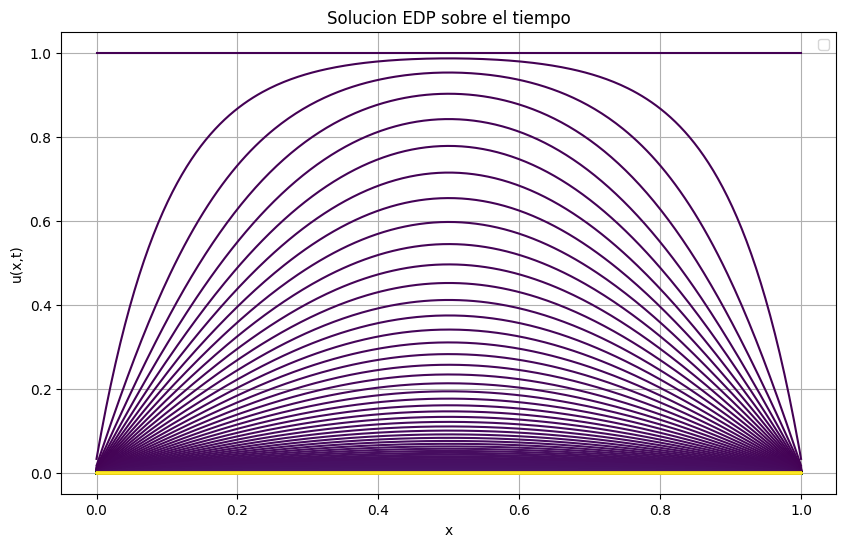

In [ ]:
def a2_func(x):
   return 1

def a1_func(x):
   return 0

def a0_func(x):
   return 0

coef_borde_ini= [1 , 0 , 0]
coef_borde_fin= [1 , 0 , 0]
n =300
L = 1
M=1000
T_max=10
dt=t_max=10/M
A, no_homogeneo= edp_lineal(a2_func, a1_func, a0_func, coef_borde_ini,coef_borde_fin, n, L)

T, T_valores_propios, norma_T = euler_implicito_dt(A, dt)
def u0(x):
  return np.ones_like(x)


xx = np.linspace(0, L, n)

U0 = u0(xx[1:-1])
x_values = np.linspace(0, 1, n -2 )


Tiempos = np.arange(0, M * dt, dt)

colors = plt.cm.get_cmap('viridis', len(range(M)))

# Create the plot
plt.figure(figsize=(10, 6))

for m in range(M):
  U = U0 @ np.linalg.matrix_power(T,m)
  plt.plot(x_values, U, color=colors(m))

plt.xlabel('x')
plt.ylabel('u(x,t)')
plt.title('Solucion EDP sobre el tiempo')
plt.grid(True)
plt.legend()
plt.show()